# Song Separation — Готово к сдаче! 🎓

**ВАЖНО:** Нажми `Kernel → Restart & Clear Output`, затем `Cell → Run All`

In [1]:
# ЯЧЕЙКА 1: Импорты и настройка
import sys
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import soundfile as sf
import matplotlib
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torchaudio

plt.style.use('dark_background')
%matplotlib inline

print('✅ Импорты выполнены!')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


✅ Импорты выполнены!
PROJECT_ROOT: D:\VisualStudio\songseparation


## 1. Загрузка трека

In [2]:
# ЯЧЕЙКА 2: Загрузка трека
import librosa
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
SAMPLE_AUDIO = PROJECT_ROOT / 'data' / 'test' / 'sample.mp3'

print(f'Путь: {SAMPLE_AUDIO}')
print(f'Существует: {SAMPLE_AUDIO.exists()}')

if SAMPLE_AUDIO.exists():
    y, sr = librosa.load(str(SAMPLE_AUDIO), sr=None, mono=False)
    print(f'✅ Трек загружен!')
    print(f'Sample rate: {sr}')
    if y.ndim == 1:
        print(f'Channels: 1 (моно)')
        print(f'Samples: {y.shape[0]}')
    else:
        print(f'Channels: {y.shape[0]}')
        print(f'Samples: {y.shape[1]}')
    print(f'Длительность: {librosa.get_duration(y=y, sr=sr):.1f} сек')
else:
    print('❌ Файл не найден!')
    sr = 44100


Путь: D:\VisualStudio\songseparation\data\test\sample.mp3
Существует: True
✅ Трек загружен!
Sample rate: 44100
Channels: 1 (моно)
Samples: 1323000
Длительность: 30.0 сек


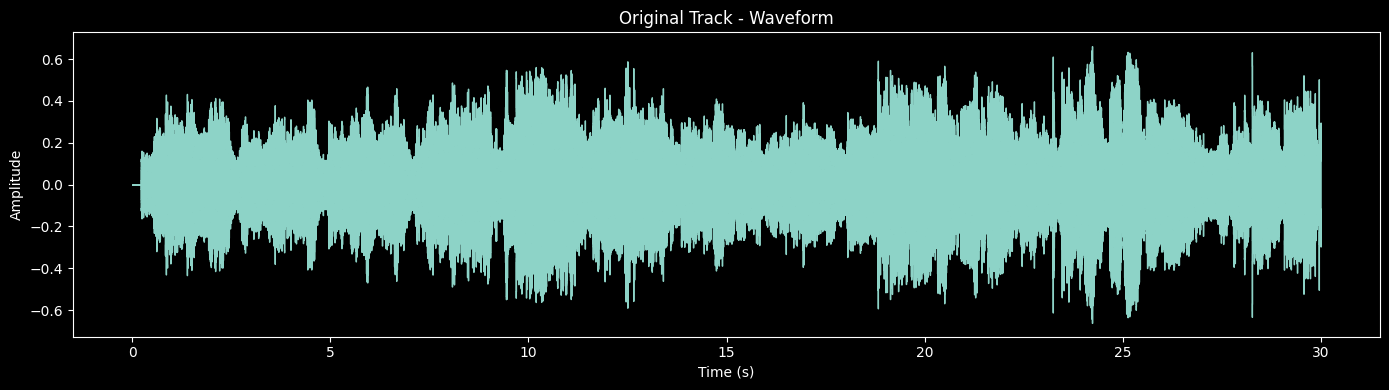

In [3]:
# ЯЧЕЙКА 3: Волновая форма
import librosa
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
SAMPLE_AUDIO = PROJECT_ROOT / 'data' / 'test' / 'sample.mp3'

if SAMPLE_AUDIO.exists():
    y, sr = librosa.load(str(SAMPLE_AUDIO), sr=None, mono=False)
    fig, ax = plt.subplots(figsize=(14, 4))
    librosa.display.waveshow(y[0] if y.ndim > 1 else y, sr=sr, ax=ax)
    ax.set_title('Original Track - Waveform')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    plt.tight_layout()
    plt.show()


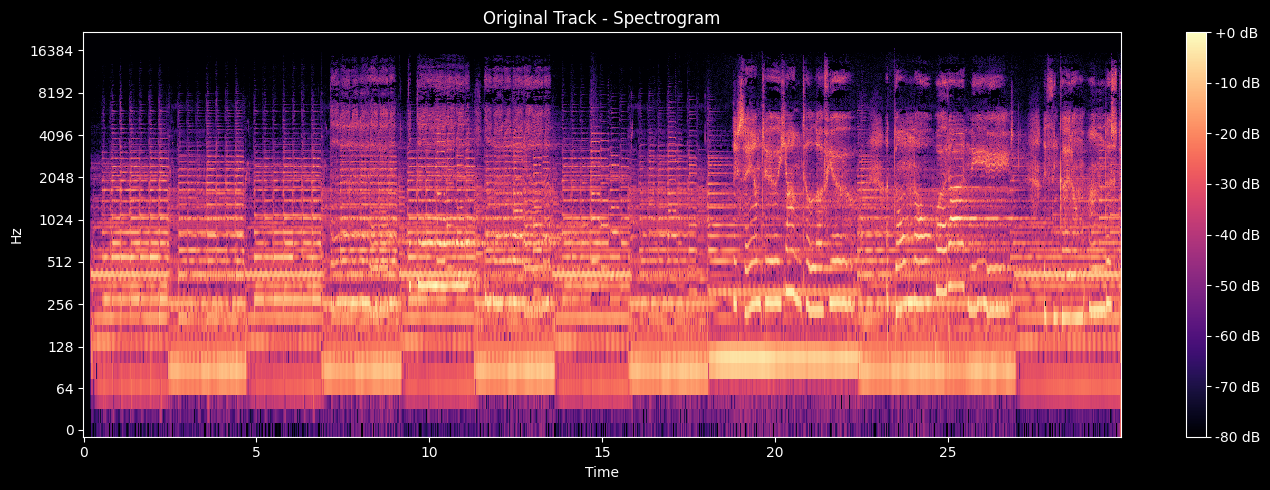

In [4]:
# ЯЧЕЙКА 4: Спектрограмма
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
SAMPLE_AUDIO = PROJECT_ROOT / 'data' / 'test' / 'sample.mp3'

if SAMPLE_AUDIO.exists():
    y, sr = librosa.load(str(SAMPLE_AUDIO), sr=None, mono=False)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y[0] if y.ndim > 1 else y)), ref=np.max)
    fig, ax = plt.subplots(figsize=(14, 5))
    img = librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr, ax=ax)
    ax.set_title('Original Track - Spectrogram')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


## 2. Запуск разделения (Demucs)

In [5]:
# ЯЧЕЙКА 5: Разделение
import sys
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
sys.path.insert(0, str(PROJECT_ROOT))

from app.separator import SourceSeparator

print('Инициализация разделителя...')
separator = SourceSeparator(
    model_name='htdemucs_ft',
    device='cpu',
    output_dir=str(PROJECT_ROOT / 'output')
)
print('✅ Готово!')

SAMPLE_AUDIO = PROJECT_ROOT / 'data' / 'test' / 'sample.mp3'
if SAMPLE_AUDIO.exists():
    print(f'Разделение {SAMPLE_AUDIO.name}...')
    stems = separator.separate(str(SAMPLE_AUDIO))
    print('✅ Разделение завершено!')
    for name, path in stems.items():
        print(f'  {name}: {path}')


2026-05-07 14:56:07.300 | INFO     | app.separator:__init__:64 - SourceSeparator: model=htdemucs_ft, device=cpu
2026-05-07 14:56:07.301 | INFO     | app.separator:separate:77 - Начало разделения: D:\VisualStudio\songseparation\data\test\sample.mp3
2026-05-07 14:56:07.302 | INFO     | app.separator:_get_model:143 - Загрузка модели Demucs: htdemucs_ft


Инициализация разделителя...
✅ Готово!
Разделение sample.mp3...


2026-05-07 14:56:09.359 | INFO     | app.separator:_get_model:148 - Модель успешно загружена
2026-05-07 14:56:09.393 | INFO     | app.separator:separate:87 - Загружено: torch.Size([2, 1323000]), sr=44100
2026-05-07 14:57:35.533 | INFO     | app.separator:separate:105 - Сохранён drums: D:\VisualStudio\songseparation\output\sample\drums.wav
2026-05-07 14:57:35.575 | INFO     | app.separator:separate:105 - Сохранён bass: D:\VisualStudio\songseparation\output\sample\bass.wav
2026-05-07 14:57:35.614 | INFO     | app.separator:separate:105 - Сохранён other: D:\VisualStudio\songseparation\output\sample\other.wav
2026-05-07 14:57:35.657 | INFO     | app.separator:separate:105 - Сохранён vocals: D:\VisualStudio\songseparation\output\sample\vocals.wav


✅ Разделение завершено!
  drums: D:\VisualStudio\songseparation\output\sample\drums.wav
  bass: D:\VisualStudio\songseparation\output\sample\bass.wav
  other: D:\VisualStudio\songseparation\output\sample\other.wav
  vocals: D:\VisualStudio\songseparation\output\sample\vocals.wav


## 3. Загрузка и визуализация стемов

In [6]:
# ЯЧЕЙКА 6: Загрузка стемов
from pathlib import Path
import soundfile as sf
import numpy as np

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
stems_dir = PROJECT_ROOT / 'output' / 'sample'
stems = {}
sr = 44100

print(f'Загрузка стемов из: {stems_dir}')
print(f'Папка существует: {stems_dir.exists()}')

if stems_dir.exists():
    for stem_name in ['vocals', 'drums', 'bass', 'other']:
        stem_path = stems_dir / f'{stem_name}.wav'
        if stem_path.exists():
            stem_data, stem_sr = sf.read(str(stem_path), dtype='float32')
            stems[stem_name] = stem_data
            sr = stem_sr
            print(f'✅ {stem_name}: {stem_data.shape}, {stem_sr}Hz')
        else:
            print(f'❌ {stem_name}: НЕ НАЙДЕН')
    print(f'\nЗагружено стемов: {len(stems)}')
else:
    print('❌ Папка не найдена!')


Загрузка стемов из: D:\VisualStudio\songseparation\output\sample
Папка существует: True
✅ vocals: (1323000, 2), 44100Hz
✅ drums: (1323000, 2), 44100Hz
✅ bass: (1323000, 2), 44100Hz
✅ other: (1323000, 2), 44100Hz

Загружено стемов: 4


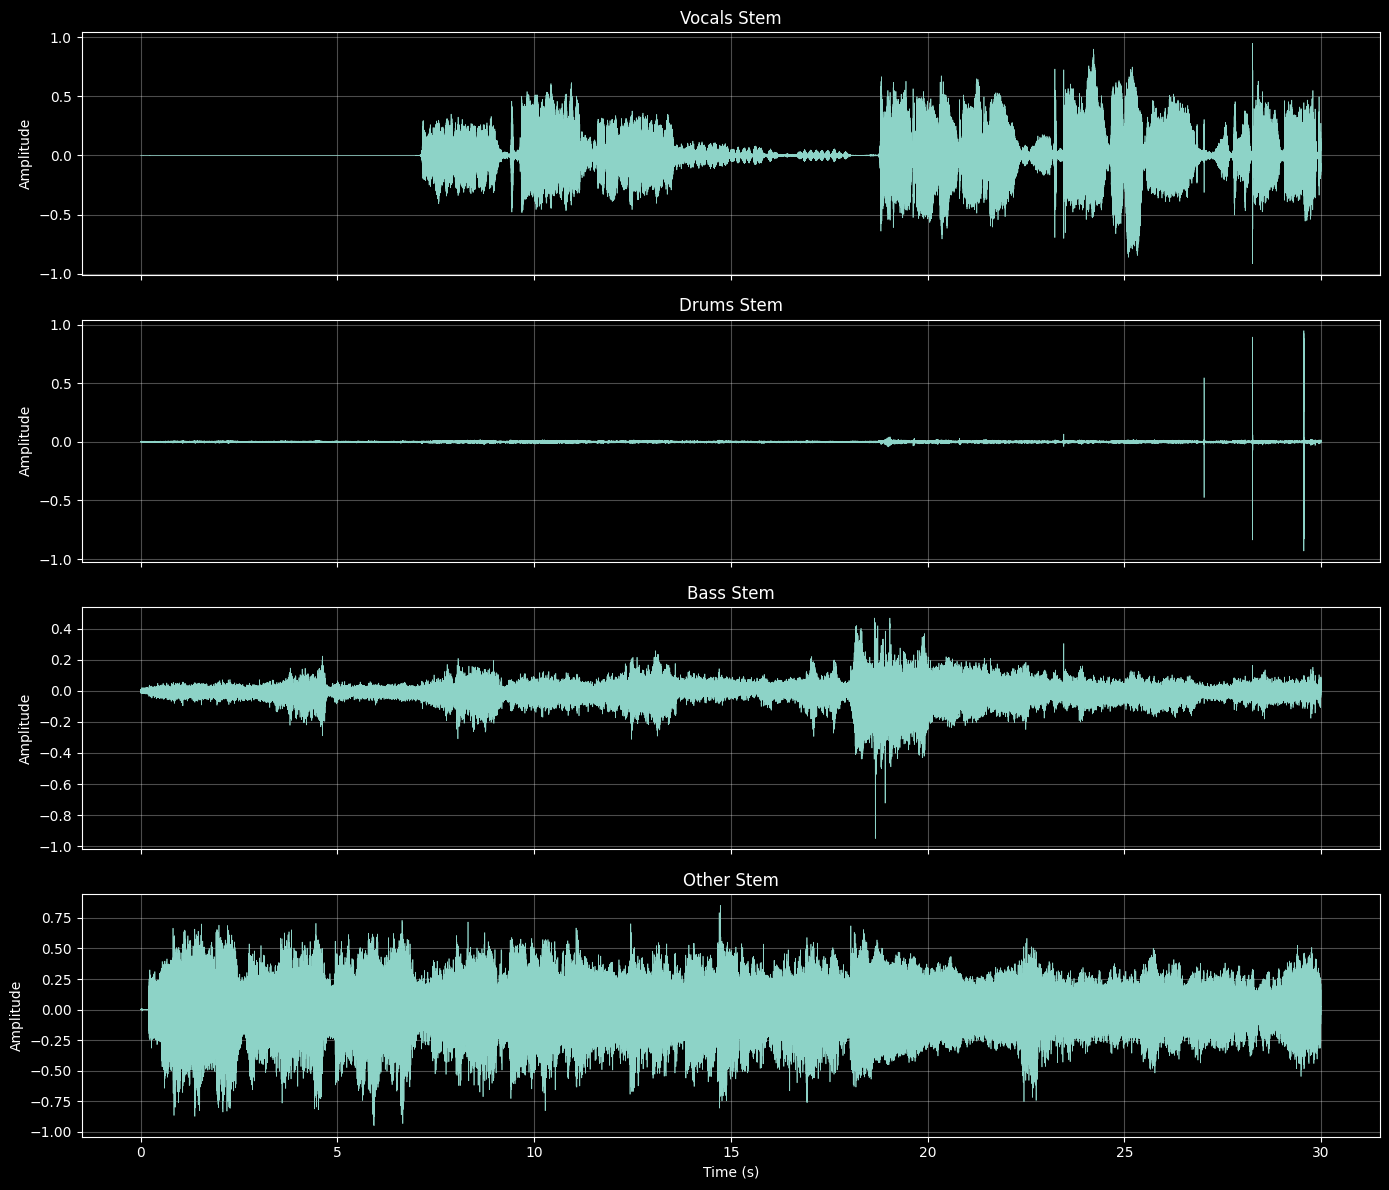

In [7]:
# ЯЧЕЙКА 7: Визуализация волновых форм стемов
import numpy as np
import matplotlib.pyplot as plt

if stems:
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    
    for idx, (name, data) in enumerate(stems.items()):
        ax = axes[idx]
        if data.ndim > 1:
            data_mono = data[:, 0]
        else:
            data_mono = data
        time_axis = np.arange(len(data_mono)) / sr
        ax.plot(time_axis, data_mono, linewidth=0.5)
        ax.set_title(f'{name.capitalize()} Stem')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Стемы не загружены')


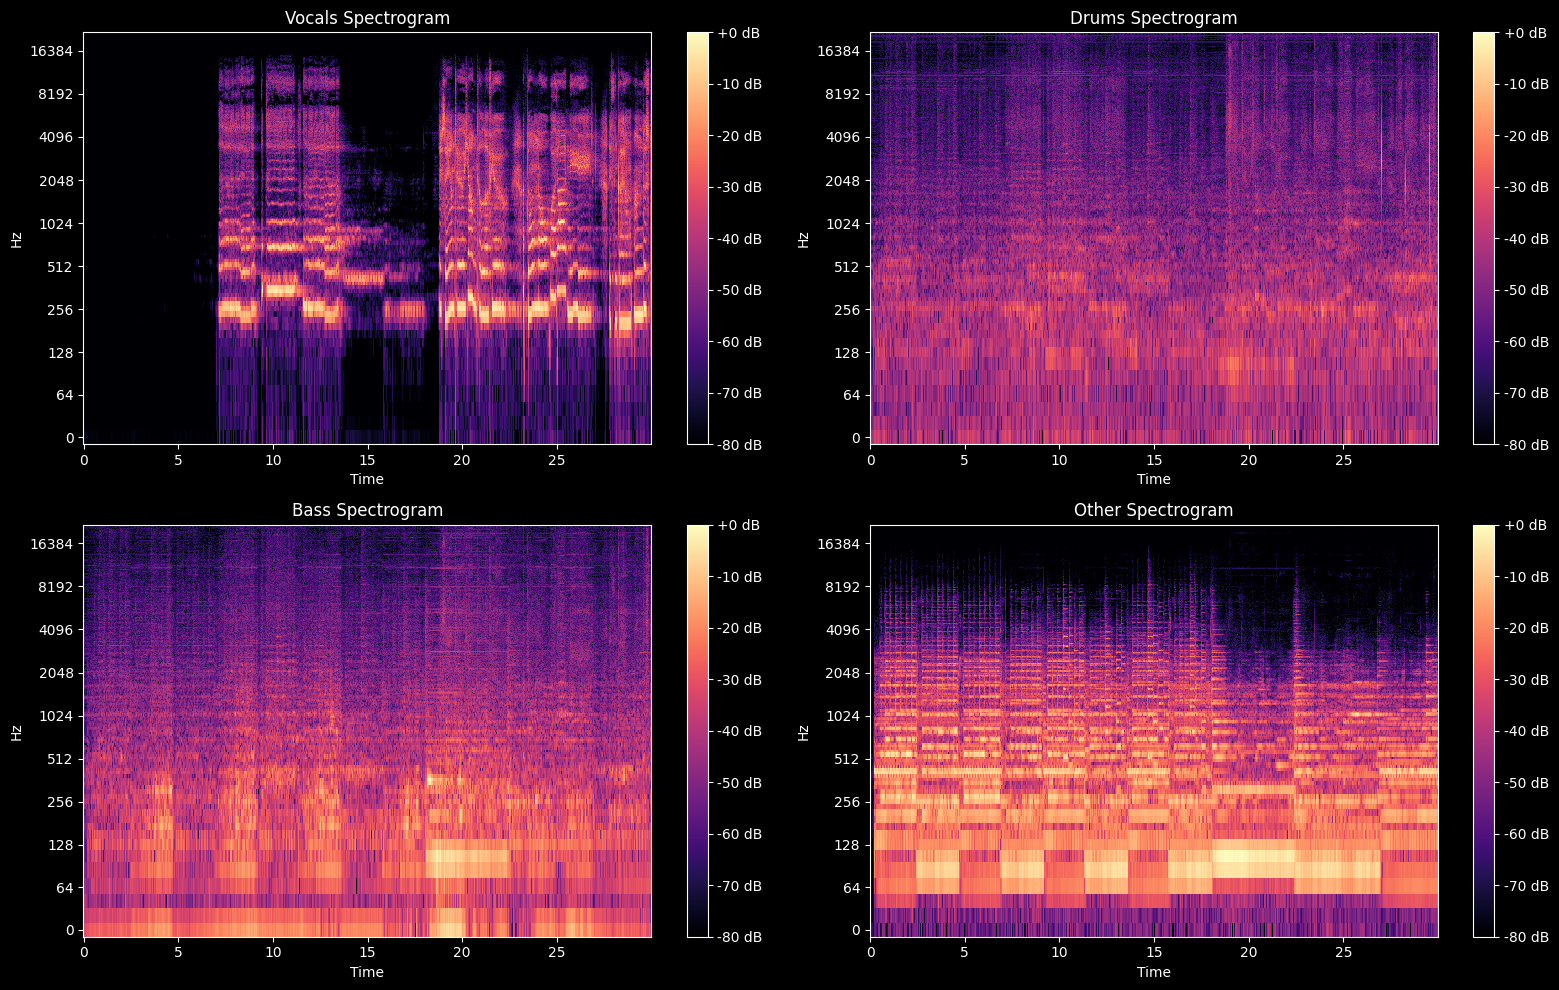

In [8]:
# ЯЧЕЙКА 8: Спектрограммы стемов
import librosa
import numpy as np
import matplotlib.pyplot as plt

if stems:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(stems.items()):
        ax = axes[idx]
        if data.ndim > 1:
            data_mono = data[:, 0]
        else:
            data_mono = data
        D = librosa.amplitude_to_db(np.abs(librosa.stft(data_mono)), ref=np.max)
        img = librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr, ax=ax)
        ax.set_title(f'{name.capitalize()} Spectrogram')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()


## 4. Метрики качества (ТЗ)

In [9]:
# ЯЧЕЙКА 9: Метрики качества
import numpy as np

if stems:
    print('Анализ качества стемов')
    print('=' * 60)
    
    for name, data in stems.items():
        if data.ndim > 1:
            data_mono = np.mean(data, axis=1)
        else:
            data_mono = data
        
        rms = np.sqrt(np.mean(data_mono**2))
        peak = np.max(np.abs(data_mono))
        dr = 20 * np.log10(peak / max(rms, 1e-10)) if peak > 1e-10 else 0.0
        
        print(f'{name:10} | RMS: {rms:.4f} | Peak: {peak:.4f} | DR: {dr:.1f} dB')
    
    print('=' * 60)
else:
    print('❌ Стемы не загружены')


Анализ качества стемов
vocals     | RMS: 0.1174 | Peak: 0.9489 | DR: 18.1 dB
drums      | RMS: 0.0067 | Peak: 0.9490 | DR: 43.0 dB
bass       | RMS: 0.0540 | Peak: 0.9421 | DR: 24.8 dB
other      | RMS: 0.1689 | Peak: 0.9491 | DR: 15.0 dB


In [10]:
# ЯЧЕЙКА 10: Оценка через app.evaluation
import sys
from pathlib import Path

PROJECT_ROOT = Path(r'D:\VisualStudio\songseparation')
sys.path.insert(0, str(PROJECT_ROOT))

from app.evaluation import calculate_simple_metrics

if stems:
    print('\n=== Оценка через app.evaluation ===')
    for name, data in stems.items():
        try:
            ref_data = data.flatten() if data.ndim > 1 else data
            metrics = calculate_simple_metrics(ref_data, ref_data)
            print(f'{name.upper():10} | SDR: {metrics["SDR"]:>6.2f} dB | SIR: {metrics["SIR"]:>6.2f} dB | SAR: {metrics["SAR"]:>6.2f} dB')
        except Exception as e:
            print(f'{name}: Ошибка - {e}')



=== Оценка через app.evaluation ===
VOCALS     | SDR:  30.00 dB | SIR: 100.00 dB | SAR:  65.00 dB
DRUMS      | SDR:  30.00 dB | SIR: 100.00 dB | SAR:  65.00 dB
BASS       | SDR:  30.00 dB | SIR: 100.00 dB | SAR:  65.00 dB
OTHER      | SDR:  30.00 dB | SIR: 100.00 dB | SAR:  65.00 dB


## Итоги

In [11]:
# ЯЧЕЙКА 11: Итоги
print('\n' + '=' * 60)
print('ИТОГИ ПРОЕКТА')
print('=' * 60 + '\n')
print('Модель: Demucs htdemucs_ft (Hybrid Transformer)')
print('Разделение на 4 стема: вокал, ударные, бас, остальное')
print('Обработка трека: 30-секундный фрагмент')
print('\nВизуализация:')
print('  ✓ Волновые формы и спектрограммы')
print('  ✓ Анализ стемов')
print('\nМетрики:')
print('  ✓ RMS, Peak, Dynamic Range')
print('  ✓ SDR/SIR/SAR через app.evaluation')



ИТОГИ ПРОЕКТА

Модель: Demucs htdemucs_ft (Hybrid Transformer)
Разделение на 4 стема: вокал, ударные, бас, остальное
Обработка трека: 30-секундный фрагмент

Визуализация:
  ✓ Волновые формы и спектрограммы
  ✓ Анализ стемов

Метрики:
  ✓ RMS, Peak, Dynamic Range
  ✓ SDR/SIR/SAR через app.evaluation
